In [6]:
import numpy as np
import math
import matplotlib.pyplot as plt

### Adaptive Hedge algorithm with adaptive learning rate

In [7]:
# AdaHedge algorithm
# takes loss matrix M
def AdaHedge(phi, M):

    #using shape of loss matrix to determine actions K and rounds T
    K, T = np.shape(M)

    #initialize weight matrix W with size as K * T
    W = np.zeros([K, T], dtype=float)

    #initialize learning rate n
    n=phi

    #initializing Regret vector with length T
    R = np.zeros(T, dtype=float)

    #creating vector of exponentials using n learning rate and L matrix of cumulative losses
    #which is reinitialized after each iteration of T
    #exponential = np.zeros(K, dtype=float)

    #cumulative weighted loss for computation of cumulative regret
    w_l = 0

    #L matrix of cumulative losses using M loss matrix 
    L = np.zeros([K,T],dtype=float)
    for i in range(K):
        for j in range(T):  
            L[i,j] = np.sum(M[i,:j+1])

    #counter for segments
    m=0

    #now for all rounds
    for t in range(T): #0,...,T-1
        if t == 0 or delta >= budget:
            m +=1
            #new learning rate
            n = n/phi

            #new budget with scaled down learning rate n
            budget = (1/(math.e-1)+1/n)*np.log(K)
            #print("AdaHedge algorithm, new budget =", budget, ", n =", n)
            
            delta = 0
            
            W[:,t] = 1/K #all equal
    
        delta = delta + np.dot(W[:,t], M[:,t]) + 1/n * np.log(np.dot(W[:,t], np.exp(-n*M[:,t])))

        if t!=T-1: #at last round no need for next weights
            
            W[:,t+1] = (W[:,t] * np.exp(-n * M[:, t])) / np.dot(W[:,t],np.exp(-n * M[:, t]))

        w_l = w_l + np.dot(W[:,t], M[:,t])

        R[t] = w_l - np.min(L[:,t])
        
    return R,m


### Hedge algorithm with three different learning rates

In [8]:
# Hedge algorithm

#two different learning rates n for hedge algorithm
#

#n1 = np.sqrt((2*np.log(K))/T)

#n2 and n3 use values of cumulative loss of last round(more theoretical)
#n2=np.sqrt(2*np.log(K)/np.min(L[:,T-1]))

#n3=np.log(1+np.sqrt((2*np.log(K))/np.min(L[:,T-1])))


def Hedge(M,n):

    #using shape of loss matrix to determine actions K and rounds T
    K, T = np.shape(M)

    #initialize weight matrix W with size as K * T
    W = np.zeros([K, T], dtype=float)

    #initializing Regret vector with length T
    R = np.zeros(T, dtype=float)

    #cumulative weighted loss for cumulative regret
    w_l = 0

    #L matrix of cumulative losses using M loss matrix 
    L = np.zeros([K,T],dtype=float)
    for i in range(K):
        for j in range(T):  
            L[i,j] = np.sum(M[i,:j+1])
    
    #initialize fixes learning rates n1 or n2 using L matrix

    if n=='n1':
        n = np.sqrt((2*np.log(K))/T)
    elif n=='n2':
        n = np.sqrt(2*np.log(K)/np.min(L[:,T-1]))
    elif n=='n3':
        n = np.log(1+np.sqrt((2*np.log(K))/np.min(L[:,T-1])))
    #print('learning rate =', n)

    W[:,0] = 1/K

    #now for all rounds
    for t in range(T): 
        if t!=T-1:
            W[:,t+1] = (W[:,t] * np.exp(-n * M[:, t])) / np.dot(W[:,t],np.exp(-n * M[:, t]))

        w_l = w_l + np.dot(W[:,t], M[:,t])

        R[t] = w_l - np.min(L[:,t])


    return R

***

### First setup
Stochastic synthetic losses of binomial distribution

In [9]:
K = 4 
T = 10000 
runs = 10

segments = np.zeros(runs)
AdaHedge_stoch = np.zeros([runs,T], dtype=float)
Hedge_n1_stoch = np.zeros([runs,T], dtype=float)
Hedge_n2_stoch = np.zeros([runs,T], dtype=float)
Hedge_n3_stoch = np.zeros([runs,T], dtype= float)

for x in range(runs):
    np.random.seed(42+x)
    action_1 = np.random.binomial(n=1, p=0.3, size=10000)
    action_2 = np.random.binomial(n=1, p=0.5, size=10000)
    action_3 = np.random.binomial(n=1, p=0.5, size=10000)
    action_4 = np.random.binomial(n=1, p=0.5, size=10000)

    M = np.array([action_1, action_2, action_3, action_4],dtype=float)

    AdaHedge_stoch[x,:], segments[x] = AdaHedge(phi=2, M=M)
    Hedge_n1_stoch[x,:] = Hedge(M=M,n='n1')
    Hedge_n2_stoch[x,:] = Hedge(M=M,n='n2')
    Hedge_n3_stoch[x,:] = Hedge(M=M,n='n3')

#saving last run of experiment's loss matrix
M_stoch = np.copy(M)

In [10]:
#average number of segments started during 10 runs of AdaHedge algorithm
np.mean(segments)


np.float64(1.2)

### Cumulative loss plot of stochastic setting

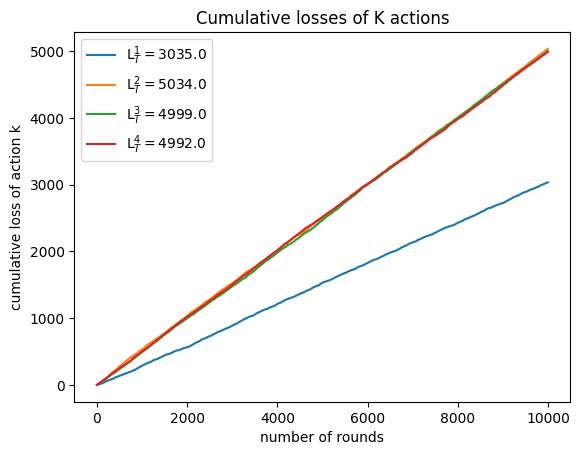

In [11]:
#Cumulative loss matrix for last run of M
K, T = np.shape(M_stoch)
L = np.zeros([K,T],dtype=float)
for i in range(K):
        for j in range(T):  
            L[i,j] = np.sum(M_stoch[i,:j+1])

#plotting cumulative losses for all actions

#plt.subplots(figsize=(7,5))
for k in range(K):  
    plt.plot(L[k,:], label=rf'$\mathrm{{L}}_T^{k+1} = {L[k,T-1]:.1f}$')
plt.xlabel('number of rounds')
plt.ylabel('cumulative loss of action k')
plt.legend()
#plt.savefig('cumulative_loss_1.png', dpi=300)
plt.title('Cumulative losses of K actions')
plt.show()



### Regret curves plot

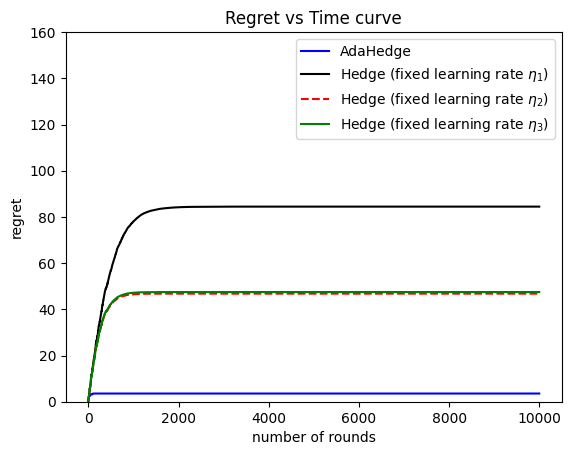

In [12]:
# Average regret curve for AdaHedge algorithm
R_AdaHedge_stoch = np.mean(AdaHedge_stoch,axis=0)

# Average regret curves for Hedge algorithms with three different learning rates
R_Hedge_n1_stoch = np.mean(Hedge_n1_stoch, axis=0)
R_Hedge_n2_stoch = np.mean(Hedge_n2_stoch, axis=0)
R_Hedge_n3_stoch = np.mean(Hedge_n3_stoch, axis = 0)

#plt.subplots(figsize=(8,5))
plt.xlabel('number of rounds')
plt.ylabel('regret')
plt.plot(R_AdaHedge_stoch, label = 'AdaHedge', color = 'b')
plt.plot(R_Hedge_n1_stoch, label = r'Hedge (fixed learning rate $\eta_1$)', color ='k')
plt.plot(R_Hedge_n2_stoch, '--', label = r'Hedge (fixed learning rate $\eta_2$)', color='r')
plt.plot(R_Hedge_n3_stoch, label = r'Hedge (fixed learning rate $\eta_3$)', color='g' )
plt.legend()
plt.ylim(0,160)
#plt.savefig("regret_1.png", dpi=300)
plt.title('Regret vs Time curve')
plt.show()


***

### Second setup
Synthetic losses of normal distributions with low gap between mean values

In [13]:
K = 4
T = 10000 
runs = 10

segments = np.zeros(runs)
AdaHedge_lowgap = np.zeros([runs,T], dtype=float)
Hedge_n1_lowgap = np.zeros([runs,T], dtype=float)
Hedge_n2_lowgap = np.zeros([runs,T], dtype=float)
Hedge_n3_lowgap = np.zeros([runs,T], dtype=float)

for x in range(runs):
    np.random.seed(42+x)
    action_1 = np.random.normal(loc=0.49, scale=0.05, size=10000)
    action_2 = np.random.normal(loc=0.5, scale=0.05, size=10000)
    action_3 = np.random.normal(loc=0.5, scale=0.05, size=10000)
    action_4 = np.random.normal(loc=0.5, scale=0.05, size=10000)

    M = np.array([action_1, action_2, action_3, action_4],dtype=float)

    #AdaHedge algorithm and number of segments started in each run
    AdaHedge_lowgap[x,:], segments[x] = AdaHedge(phi=2, M=M)

    #Hedge algorithms with two values of learning rate

    Hedge_n1_lowgap[x,:] = Hedge(M=M,n='n1')
    
    Hedge_n2_lowgap[x,:] = Hedge(M=M,n='n2')
    Hedge_n3_lowgap[x,:] = Hedge(M=M,n='n3')

M_lowgap = np.copy(M)


### Cumulative loss plot of low gap setting

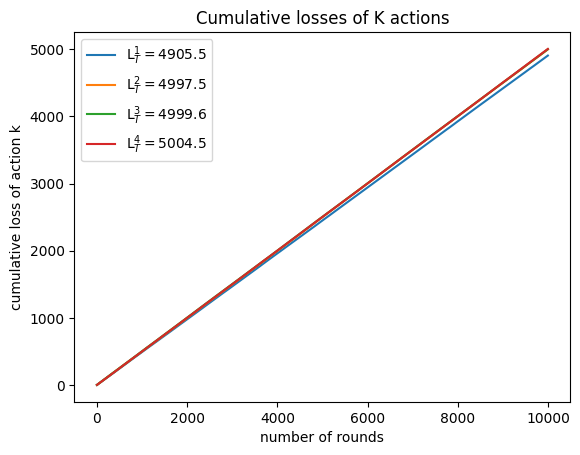

In [14]:
#Cumulative loss matrix for last run of M
#L matrix of cumulative losses using M loss matrix 
K, T = np.shape(M_lowgap)
L = np.zeros([K,T],dtype=float)
for i in range(K):
        for j in range(T):  
            L[i,j] = np.sum(M_lowgap[i,:j+1])

for k in range(K):  
    plt.plot(L[k,:], label=rf'$\mathrm{{L}}_T^{k+1} = {L[k,T-1]:.1f}$')
plt.xlabel('number of rounds')
plt.ylabel('cumulative loss of action k')
plt.legend()
#plt.savefig('cumulative_loss_2.png',dpi=300)
plt.title('Cumulative losses of K actions')
plt.show()

### Regret curve plot

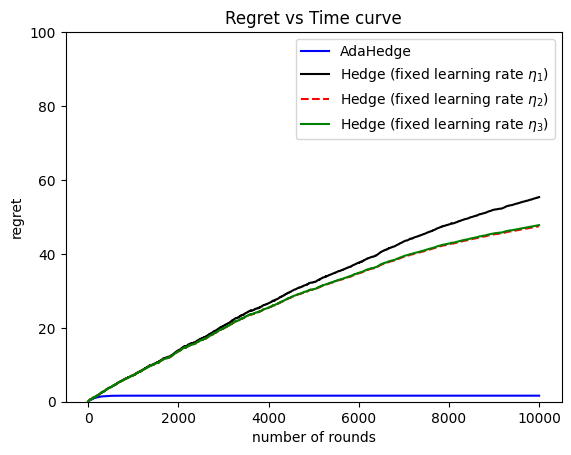

In [15]:
R_AdaHedge_lowgap = np.mean(AdaHedge_lowgap,axis=0)

R_Hedge_n1_lowgap = np.mean(Hedge_n1_lowgap, axis=0)
R_Hedge_n2_lowgap = np.mean(Hedge_n2_lowgap, axis=0)
R_Hedge_n3_lowgap = np.mean(Hedge_n3_lowgap, axis=0)

plt.xlabel('number of rounds')
plt.ylabel('regret')
plt.plot(R_AdaHedge_lowgap, label = 'AdaHedge', color = 'b')
plt.plot(R_Hedge_n1_lowgap, label = r'Hedge (fixed learning rate $\eta_1$)', color ='k')
plt.plot(R_Hedge_n2_lowgap, '--', label = r'Hedge (fixed learning rate $\eta_2$)', color='r')
plt.plot(R_Hedge_n3_lowgap, label = r'Hedge (fixed learning rate $\eta_3$)', color='g')
plt.legend()
plt.ylim(0,100)
#plt.savefig('regret_2.png', dpi=300)
plt.title('Regret vs Time curve')
plt.show()

***

### Third setup
Adversarial setting where best expert changes

In [16]:
#best expert changes over time in blocks

K = 3
T = 10000 
runs = 10

segments = np.zeros(runs)

r_a = np.zeros([runs,T], dtype=float)
r_h1 = np.zeros([runs,T], dtype=float)
r_h2 = np.zeros([runs,T], dtype=float)
r_h3 = np.zeros([runs,T], dtype=float)

for i in range(runs):
    np.random.seed(42+i)
    x1 = np.random.binomial(1, 0.4, 5000)
    x2 = np.random.binomial(1, 0.5, 5000)
    x = np.append(x1, x2)

    y1 = np.random.binomial(1, 0.5, 5000)
    y2 = np.random.binomial(1, 0.2, 5000)
    y = np.append(y1, y2)

    z = np.random.binomial(1, 0.5, 10000)


    losses = np.array([x, y, z], dtype=float)
    
    r_a[i,:], segments[i] = AdaHedge(phi=2, M=losses)
    r_h1[i,:] = Hedge(M=losses, n='n1')
    r_h2[i,:] = Hedge(M=losses, n='n2')
    r_h3[i,:] = Hedge(M=losses, n='n3')

M_advers = np.copy(losses)

In [17]:
#average number of new segments per run in AdaHedge
np.mean(segments)

np.float64(2.5)

### Cumulative loss plot of adversarial setting

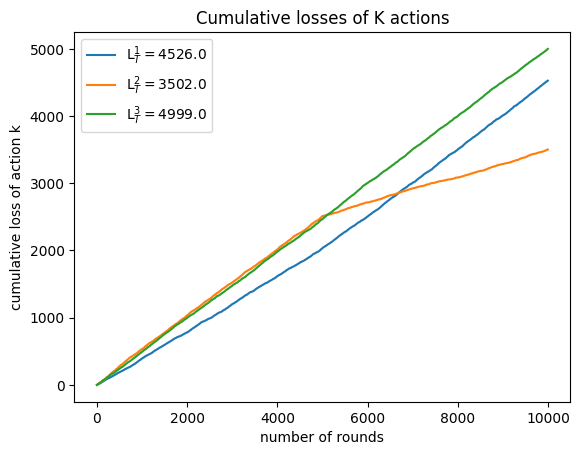

In [18]:
#Cumulative loss matrix for last run of M
#L matrix of cumulative losses using M loss matrix 
K, T = np.shape(M_advers)
L = np.zeros([K,T],dtype=float)
for i in range(K):
        for j in range(T):  
            L[i,j] = np.sum(M_advers[i,:j+1])

for k in range(K):  
    plt.plot(L[k,:], label=rf'$\mathrm{{L}}_T^{k+1} = {L[k,T-1]:.1f}$')
plt.xlabel('number of rounds')
plt.ylabel('cumulative loss of action k')
plt.legend()
#plt.savefig('cumulative_loss_3.png',dpi=300)
plt.title('Cumulative losses of K actions')
plt.show()

### Regret curves plot

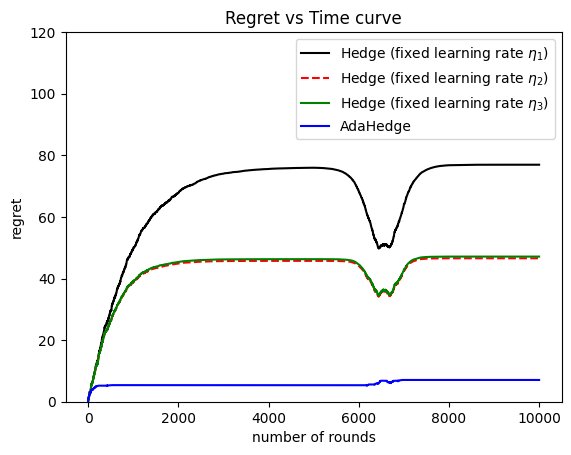

In [28]:
plt.xlabel('number of rounds')
plt.ylabel('regret')
plt.plot(np.mean(r_h1,axis=0), label = r'Hedge (fixed learning rate $\eta_1$)', color ='k')
plt.plot(np.mean(r_h2,axis=0), '--', label = r'Hedge (fixed learning rate $\eta_2$)', color='r')
plt.plot(np.mean(r_h3,axis=0), label = r'Hedge (fixed learning rate $\eta_3$)', color='g')
plt.plot(np.mean(r_a,axis=0), label = 'AdaHedge', color = 'b')
plt.ylim(0,120)
plt.legend()
#plt.savefig('regret_3.png', dpi=300)
plt.title('Regret vs Time curve')
plt.show()

___

### Additional plots

### Additional settings with FTL algorithm compared together

In [20]:
#quick FTL algorithm

def FTL(M):

    #using shape of loss matrix to determine actions K and rounds T
    K, T = np.shape(M)

    #initialize weight matrix W with size as K * T
    W = np.zeros([K, T], dtype=float)

    #initializing Regret vector with length T
    R = np.zeros(T, dtype=float)

    #weighted loss for easier computation of regret
    w_l = 0

    #L matrix of cumulative losses using M loss matrix 
    L = np.zeros([K,T],dtype=float)
    for i in range(K):
        for j in range(T):  
            L[i,j] = np.sum(M[i,:j+1])
  
    #now for all rounds
    for t in range(T):
        if t == 0:
            W[:,t] = 1/K #all equal
        
        #finding which action has least cumulative loss at t
        index = np.argmin(L[:,t])
        if t!=T-1:
            #next round action with least cumul loss at current gets all weight prob
            W[index,t+1] = 1

        w_l = w_l + np.dot(W[:,t], M[:,t])

        R[t] = w_l - np.min(L[:,t])
        
    return R

    

- Comparing FTL with AdaHedge and Hedge in the first setup (stochastic)

Regret curve plot

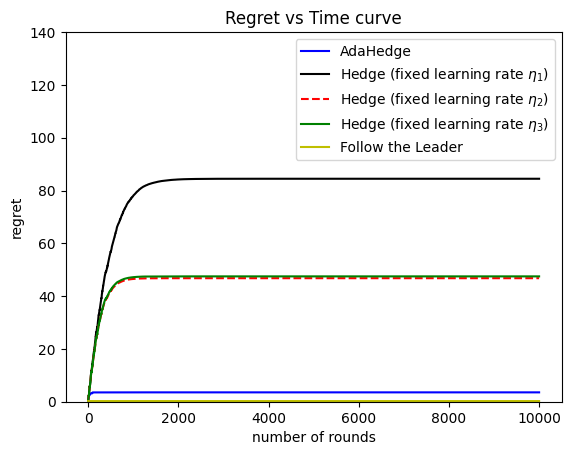

In [21]:
#FTL regret curve using M matrix of synthetic stochastic losses 
R_FTL = FTL(M=M_stoch)

plt.title('Regret vs Time curve')
plt.xlabel('number of rounds')
plt.ylabel('regret')
plt.plot(R_AdaHedge_stoch, label = 'AdaHedge', color = 'b')
plt.plot(R_Hedge_n1_stoch, label = r'Hedge (fixed learning rate $\eta_1$)', color ='k')
plt.plot(R_Hedge_n2_stoch, '--', label = r'Hedge (fixed learning rate $\eta_2$)', color='r')
plt.plot(R_Hedge_n3_stoch, label = r'Hedge (fixed learning rate $\eta_3$)', color='g' )
plt.plot(R_FTL, label = 'Follow the Leader', color='y')
plt.legend()
plt.ylim(0,140)
plt.show()

- Comparing FTL with AdaHedge and Hedge in the second setup (low gap)

Regret curve plot

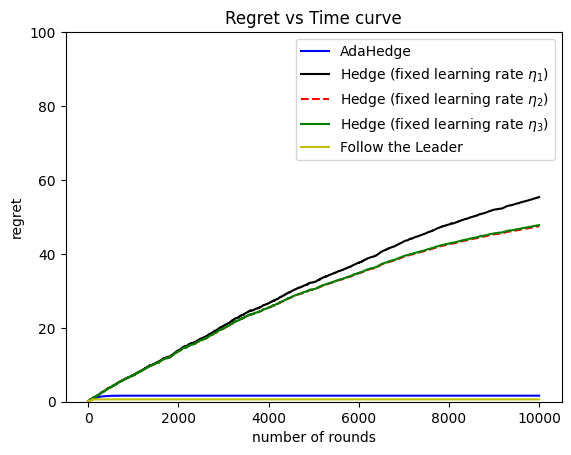

In [22]:
R_FTL = FTL(M_lowgap)

plt.title('Regret vs Time curve')
plt.xlabel('number of rounds')
plt.ylabel('regret')
plt.plot(R_AdaHedge_lowgap, label = 'AdaHedge', color = 'b')
plt.plot(R_Hedge_n1_lowgap, label = r'Hedge (fixed learning rate $\eta_1$)', color ='k')
plt.plot(R_Hedge_n2_lowgap, '--', label = r'Hedge (fixed learning rate $\eta_2$)', color='r')
plt.plot(R_Hedge_n3_lowgap, label = r'Hedge (fixed learning rate $\eta_3$)', color='g')
plt.plot(R_FTL, label = 'Follow the Leader', color='y')
plt.legend()
plt.ylim(0,100)
plt.show()

- Comparing FTL with AdaHedge and Hedge in the third setup (adversarial)

Regret curves plot

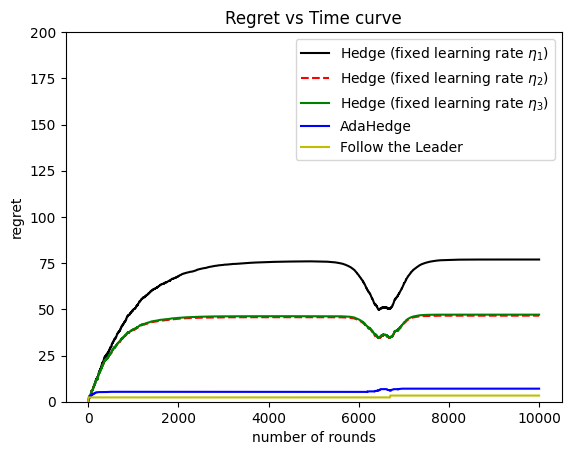

In [23]:
#FTL regret curve using M matrix of synthetic adversarial losses 
R_FTL = FTL(M=M_advers)

plt.title('Regret vs Time curve')
plt.xlabel('number of rounds')
plt.ylabel('regret')
plt.plot(np.mean(r_h1,axis=0), label = r'Hedge (fixed learning rate $\eta_1$)', color ='k')
plt.plot(np.mean(r_h2,axis=0), '--', label = r'Hedge (fixed learning rate $\eta_2$)', color='r')
plt.plot(np.mean(r_h3,axis=0), label = r'Hedge (fixed learning rate $\eta_3$)', color='g')
plt.plot(np.mean(r_a,axis=0), label = 'AdaHedge', color = 'b')
plt.plot(R_FTL, label = 'Follow the Leader', color='y')
plt.legend()
plt.ylim(0,200)
plt.show()

---

### Alternating adversarial setting

In [33]:
K=2
T=1000

action_1 = np.zeros(T,dtype=float)
action_2 = np.zeros(T, dtype=float)

for i in range(T): 
    if i%2==0: action_1[i] = 1 
    else: action_2[i] = 1
action_1[0] = 1/2

M_advers_alter = np.array([action_1, action_2])

#AdaHedge algorithm
R_AdaHedge_advers, segments = AdaHedge(phi=2, M=M_advers_alter)

#Hedge algorithms
R_Hedge_n1_advers = Hedge(M=M_advers_alter,n='n1')
R_Hedge_n2_advers = Hedge(M=M_advers_alter,n='n2')
R_Hedge_n3_advers = Hedge(M=M_advers_alter,n='n3')



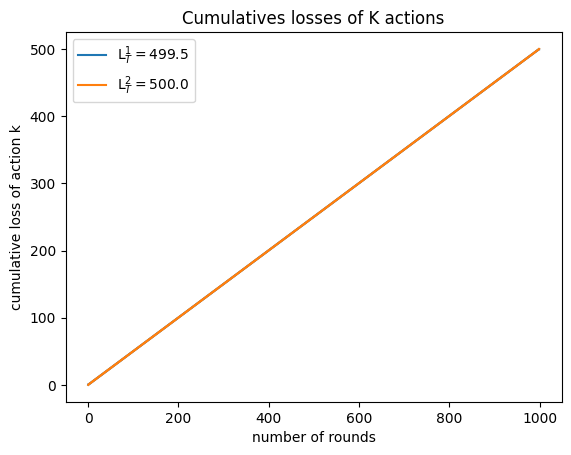

In [34]:
#Cumulative loss matrix for M
#L matrix of cumulative losses using M_advers(adversarial)
K, T = np.shape(M_advers_alter)
L = np.zeros([K,T],dtype=float)
for i in range(K):
        for j in range(T):  
            L[i,j] = np.sum(M_advers_alter[i,:j+1])

#plt.subplots(figsize=(7,5))

plt.plot(L[0,:], label=rf'$\mathrm{{L}}_T^1 = {L[0,T-1]:.1f}$')
plt.plot(L[1,:], label=rf'$\mathrm{{L}}_T^2 = {L[1,T-1]:.1f}$')
plt.xlabel('number of rounds')
plt.ylabel('cumulative loss of action k')
plt.legend()
#plt.savefig('cumulative_loss_4.png', dpi=300)
plt.title('Cumulatives losses of K actions')
plt.show()

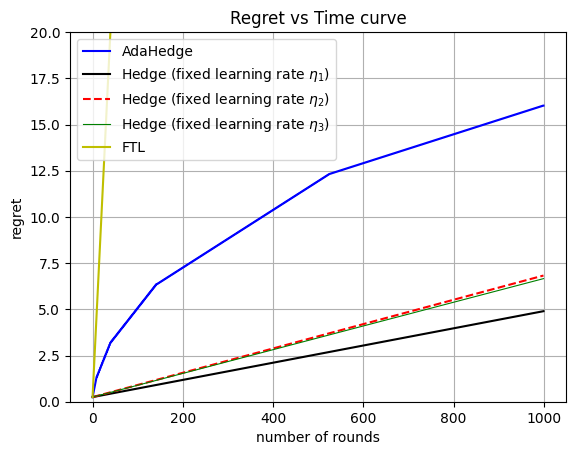

In [36]:
#plt.subplots(figsize=(8,5))
plt.xlabel('number of rounds')
plt.ylabel('regret')
plt.plot(R_AdaHedge_advers, label = 'AdaHedge', color = 'b')
plt.plot(R_Hedge_n1_advers, label = r'Hedge (fixed learning rate $\eta_1$)', color ='k')
plt.plot(R_Hedge_n2_advers, '--', label = r'Hedge (fixed learning rate $\eta_2$)', color='r')
plt.plot(R_Hedge_n3_advers, label = r'Hedge (fixed learning rate $\eta_3$)', linewidth = 0.8, color='g')
plt.plot(FTL(M_advers_alter), label = 'FTL', color='y')
plt.legend()
plt.ylim(0,20)
#plt.savefig('regret_4.png', dpi=300)
plt.title('Regret vs Time curve')
plt.grid()
plt.show()